In [1]:
import glob 
import os
import numpy as np

from data_utils import parse_p2s, load_s_e_l_segs, segment_lengths, generate_more_segments, split_eat_noneat

from tqdm import tqdm

In [2]:
def find_all_labelled_files(root_dir):
    files=glob.glob(root_dir+"/*")
    for file in files:
        if "toupload" in file:
            files.remove(file)
    # print(files)

    segments_files=[]

    file=files[0]
    for file in files:
        segments_all=glob.glob(file+"/**/segments.txt",recursive=True) 
        for segment in segments_all:
            if "cam1" in segment and not "pill" in segment:
                segments_files.append(segment)

    len(segments_files)

     
    dir_segs={}
    for filename in segments_files:
        try:
            dir_segs[filename]=load_s_e_l_segs(filename)
        except Exception as e:
            print("Error in loading file", filename)
            print(e)
            print('-------------------')
    return dir_segs

### Loading Test data

In [3]:
test_dir="/media/ns/Seagate/oct18"

In [4]:
dir_segs=find_all_labelled_files(test_dir)
print(f"Total segments.txt files found: {len(dir_segs)}")

Total segments.txt files found: 9


In [5]:
# seg_files=list(dir_segs.keys())
# seg_files

In [6]:
eating_file2segs, not_eating_file2segs=split_eat_noneat(dir_segs)
print(f"Total eating segments: {sum([len(v) for v in eating_file2segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_file2segs.values()])}")

Total eating segments: 48
Total not eating segments: 65


In [7]:
de=segment_lengths(eating_file2segs)
dne=segment_lengths(not_eating_file2segs)

print(f"Total eating segments: {len(de)}")
print(f"Total not eating segments: {len(dne)}")

print(f"min eating segment: {min(de)}")
print(f"max eating segment: {max(de)}") 
print(f"min not eating segment: {min(dne)}")
print(f"max not eating segment: {max(dne)}")
print(f"median eating segment: {np.median(de)}")
print(f"median not eating segment: {np.median(dne)}")

Total eating segments: 48
Total not eating segments: 65
min eating segment: 30
max eating segment: 447
min not eating segment: 31
max not eating segment: 709
median eating segment: 109.0
median not eating segment: 58.0


In [8]:
seq_length=30

eating_segs=generate_more_segments(eating_file2segs, seq_length=seq_length, max_overlap=10)
not_eating_segs=generate_more_segments(not_eating_file2segs, seq_length=seq_length, max_overlap=10)

print('Fixed length segments: ', seq_length)
print(f"Total eating segments: {sum([len(v) for v in eating_segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_segs.values()])}")

Fixed length segments:  30
Total eating segments: 252
Total not eating segments: 211


In [9]:
#create dataset
all_rows_eating=[]
for filepath in eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_eating.append(rows)

all_rows_eating=np.concatenate(all_rows_eating, axis=0)

all_rows_not_eating=[]
for filepath in not_eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=not_eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_not_eating.append(rows)
all_rows_not_eating=np.concatenate(all_rows_not_eating, axis=0)

all_rows_eating.shape, all_rows_not_eating.shape

((252, 30, 50), (211, 30, 50))

In [10]:
X_test=np.concatenate([all_rows_eating, all_rows_not_eating], axis=0)
y_test=np.concatenate([np.ones(all_rows_eating.shape[0]), np.zeros(all_rows_not_eating.shape[0])], axis=0)
X_test.shape, y_test.shape

((463, 30, 50), (463,))

### Loading training data

In [11]:
filepath_oct25="/media/ns/Seagate/oct25"
filepath_nov6="/media/ns/Seagate/nov6"
filepath_nov8="/media/ns/Seagate/nov8"
filepath_nov15="/media/ns/Seagate/nov15"

In [12]:

files_oct25=glob.glob(filepath_oct25+"/*")
for file in files_oct25:
    if 'toupload' in file:
        del files_oct25[files_oct25.index(file)]
files_oct25

['/media/ns/Seagate/oct25/madison',
 '/media/ns/Seagate/oct25/amy',
 '/media/ns/Seagate/oct25/cassidy']

In [13]:
files_nov6=glob.glob(filepath_nov6+"/*")
for file in files_nov6:
    #if it is a file
    if os.path.isfile(file):
        del files_nov6[files_nov6.index(file)]
    if 'toupload' in file:
        del files_nov6[files_nov6.index(file)] 
for file in files_nov6: 
    if 'need' in file: 
        del files_nov6[files_nov6.index(file)]
for file in files_nov6: 
    if 'labelled' in file: 
        del files_nov6[files_nov6.index(file)]
files_nov6

['/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/katie',
 '/media/ns/Seagate/nov6/katy',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/ashley',
 '/media/ns/Seagate/nov6/makalyah',
 '/media/ns/Seagate/nov6/ana']

In [14]:
len(files_nov6)

10

In [15]:
#remove issues.
issues=['katy', 'katie', 'ana', 'ashley']
for issue in issues:
    for file in files_nov6:
        if issue in file:
            del files_nov6[files_nov6.index(file)]
            
files_nov6

['/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/makalyah']

In [16]:

files_nov8=glob.glob(filepath_nov8+"/*")
for file in files_nov8:
    if 'toupload' in file:
        del files_nov8[files_nov8.index(file)]
files_nov8

['/media/ns/Seagate/nov8/anna', '/media/ns/Seagate/nov8/jack']

In [17]:
files_nov15=glob.glob(filepath_nov15+"/*")
for file in files_nov15:
    if 'toupload' in file:
        del files_nov15[files_nov15.index(file)]
for file in files_nov15: 
    if 'need' in file: 
        del files_nov15[files_nov15.index(file)]
files_nov15

['/media/ns/Seagate/nov15/sheikh',
 '/media/ns/Seagate/nov15/hafizul',
 '/media/ns/Seagate/nov15/rabiul']

In [18]:
all_files=files_oct25+files_nov6+files_nov8+files_nov15
len(all_files)

14

In [19]:
dir=all_files[0]
dir_segs=find_all_labelled_files(dir)
print(f"Total segments.txt files found: {len(dir_segs)}")

Total segments.txt files found: 2


In [20]:
dir_segs_all={}
for dir in all_files:
    dir_segs=find_all_labelled_files(dir)
    print('dir=', dir)
    print(f"Total segments.txt files found: {len(dir_segs)}\n") 
    for k,v in dir_segs.items():
        dir_segs_all[k]=v

len(dir_segs_all)

dir= /media/ns/Seagate/oct25/madison
Total segments.txt files found: 2

dir= /media/ns/Seagate/oct25/amy
Total segments.txt files found: 0

dir= /media/ns/Seagate/oct25/cassidy
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/joey
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/lucy
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/patrick
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/corinna
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/jessie
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/makalyah
Total segments.txt files found: 3

dir= /media/ns/Seagate/nov8/anna
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov8/jack
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/sheikh
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/hafizul
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/rabiul
Total segments.txt files found: 2



27

In [21]:
keys=list(dir_segs_all.keys())
keys_base=keys[:10]
keys_1=keys[10:14]
keys_2=keys[14:18]
keys_3=keys[18:22]
keys_4=keys[22:27] 

dir_segs_base={k:dir_segs_all[k] for k in keys_base}
dir_segs_1={k:dir_segs_all[k] for k in keys_base+keys_1}
dir_segs_2={k:dir_segs_all[k] for k in keys_base+keys_1+keys_2}
dir_segs_3={k:dir_segs_all[k] for k in keys_base+keys_1+keys_2+keys_3}
dir_segs_4={k:dir_segs_all[k] for k in keys_base+keys_1+keys_2+keys_3+keys_4}

len(dir_segs_base), len(dir_segs_1), len(dir_segs_2), len(dir_segs_3), len(dir_segs_4), len(dir_segs_all)

(10, 14, 18, 22, 27, 27)

In [22]:
seq_length=30

In [23]:
def create_dataset(eating_segs, not_eating_segs):
    all_rows_eating=[]
    for filepath in eating_segs.keys():
        dirname=os.path.dirname(filepath)
        ses=parse_p2s(dirname)
        fixed_segs=eating_segs[filepath]
        rows=np.array([ses[s:e] for s,e in fixed_segs] )
        all_rows_eating.append(rows)

    all_rows_eating=np.concatenate(all_rows_eating, axis=0)

    all_rows_not_eating=[]
    for filepath in not_eating_segs.keys():
        dirname=os.path.dirname(filepath)
        ses=parse_p2s(dirname)
        fixed_segs=not_eating_segs[filepath]
        rows=np.array([ses[s:e] for s,e in fixed_segs] )
        all_rows_not_eating.append(rows)
    all_rows_not_eating=np.concatenate(all_rows_not_eating, axis=0)

    return all_rows_eating, all_rows_not_eating 

In [24]:
def generate_Xy(dir_segs_all):
    eating_file2segs, not_eating_file2segs=split_eat_noneat(dir_segs_all)
    eating_segs=generate_more_segments(eating_file2segs, seq_length=seq_length, max_overlap=10)
    not_eating_segs=generate_more_segments(not_eating_file2segs, seq_length=seq_length, max_overlap=10)

    all_rows_eating, all_rows_not_eating = create_dataset(eating_segs, not_eating_segs)

    X_train=np.concatenate([all_rows_eating, all_rows_not_eating], axis=0)
    y_train=np.concatenate([np.ones(all_rows_eating.shape[0]), np.zeros(all_rows_not_eating.shape[0])], axis=0)
    return X_train, y_train

In [25]:
X_train_base, y_train_base=generate_Xy(dir_segs_base)
X_train_1, y_train_1=generate_Xy(dir_segs_1)
X_train_2, y_train_2=generate_Xy(dir_segs_2)
X_train_3, y_train_3=generate_Xy(dir_segs_3)
X_train_4, y_train_4=generate_Xy(dir_segs_4)

X_train_base.shape, y_train_base.shape, X_train_1.shape, y_train_1.shape, X_train_2.shape, y_train_2.shape, X_train_3.shape, y_train_3.shape, X_train_4.shape, y_train_4.shape

((576, 30, 50),
 (576,),
 (723, 30, 50),
 (723,),
 (826, 30, 50),
 (826,),
 (1008, 30, 50),
 (1008,),
 (1176, 30, 50),
 (1176,))

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import glob 
import torch
import torch.nn as nn
import torch.optim as optim 
import time 
from torch.utils.data import DataLoader, TensorDataset

In [27]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device 

device(type='cuda')

In [28]:
# test_loader = DataLoader(
#     TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)),
#     batch_size=32, shuffle=True)

X_test_tensor=torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor=torch.tensor(y_test, dtype=torch.float32).to(device)
X_test_tensor.shape, y_test_tensor.shape

(torch.Size([463, 30, 50]), torch.Size([463]))

In [29]:
class LSTM(nn.Module):
    
    def __init__(self,input_dim,hidden_dim,output_dim,layer_num, seq_len):
        super(LSTM,self).__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lstm = torch.nn.LSTM(input_dim,hidden_dim,layer_num,batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim,output_dim)
        self.bn = nn.BatchNorm1d(seq_len)
        
    def forward(self,inputs):
        x = self.bn(inputs)
        lstm_out,(hn,cn) = self.lstm(x)
        out = self.fc(lstm_out[:,-1,:])
        return out

### Train base

In [30]:
n_hidden = 128
n_joints = 25*2
n_categories = 2
n_layer = 3
seq_len = 30

n_iters = 5_000
print_every = 100

learning_rate = 1e-5 

In [31]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_base, dtype=torch.float32), torch.tensor(y_train_base, dtype=torch.float32)),
    batch_size=64, shuffle=True)

  2%|▏         | 101/5000 [00:08<07:20, 11.12it/s]

100 4.458918273448944


  4%|▍         | 201/5000 [00:16<06:53, 11.62it/s]

200 4.118063718080521


  6%|▌         | 301/5000 [00:23<04:56, 15.87it/s]

...

4800 0.06156153359916061


 98%|█████████▊| 4902/5000 [06:08<00:07, 12.75it/s]

4900 0.052372345759067684


100%|██████████| 5000/5000 [06:16<00:00, 13.28it/s]


5000 1.159873844590038
acc= 0.5572354197502136


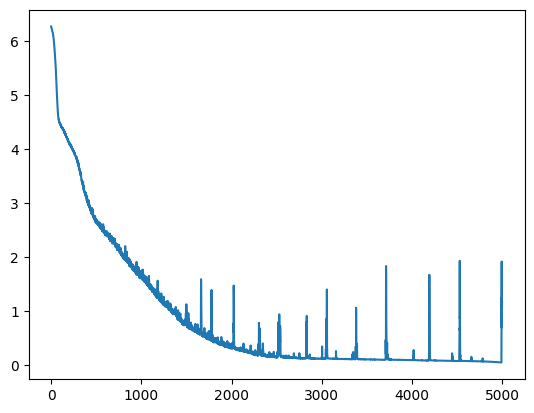

In [32]:
rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)


rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

### Train base+keys1

  2%|▏         | 100/5000 [00:08<08:03, 10.14it/s]

100 6.735703110694885


  4%|▍         | 202/5000 [00:16<04:40, 17.11it/s]

200 6.247829258441925


  6%|▌         | 301/5000 [00:25<08:56,  8.76it/s]

...

4800 0.008995442018203903


 98%|█████████▊| 4901/5000 [07:53<00:07, 12.45it/s]

4900 0.008631658289232291


100%|██████████| 5000/5000 [08:00<00:00, 10.41it/s]


5000 0.008706216292921454
acc= 0.5593952536582947


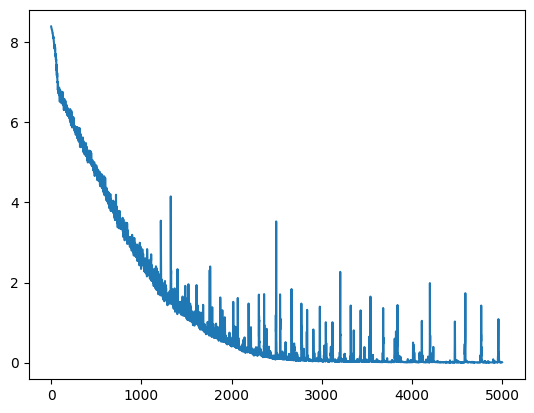

In [33]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_1, dtype=torch.float32), torch.tensor(y_train_1, dtype=torch.float32)),
    batch_size=64, shuffle=True)

rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)


all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

### Train keys2

  2%|▏         | 101/5000 [00:10<09:20,  8.74it/s]

100 7.26742160320282


  4%|▍         | 201/5000 [00:22<09:20,  8.57it/s]

200 6.728271663188934


  6%|▌         | 301/5000 [00:33<09:24,  8.32it/s]

...

4800 0.007200230757007375


 98%|█████████▊| 4901/5000 [08:34<00:10,  9.60it/s]

4900 0.04066109546693042


100%|██████████| 5000/5000 [08:43<00:00,  9.55it/s]


5000 0.020763824606547132
acc= 0.5291576385498047


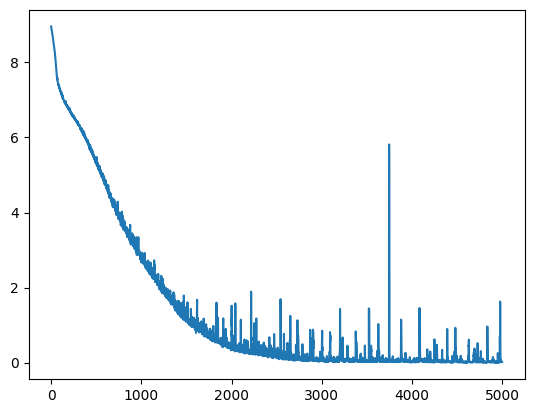

In [34]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_2, dtype=torch.float32), torch.tensor(y_train_2, dtype=torch.float32)),
    batch_size=64, shuffle=True)

rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)


all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

### Train keys3

  2%|▏         | 101/5000 [00:13<07:58, 10.23it/s]

100 8.907654225826263


  4%|▍         | 201/5000 [00:26<11:51,  6.74it/s]

200 8.083608359098434


  6%|▌         | 301/5000 [00:39<08:49,  8.87it/s]

...

4800 0.01025909477903042


 98%|█████████▊| 4901/5000 [10:48<00:11,  8.34it/s]

4900 0.005664822390826885


100%|██████████| 5000/5000 [10:59<00:00,  7.58it/s]

5000 0.006661212901235558
acc= 0.53995680809021


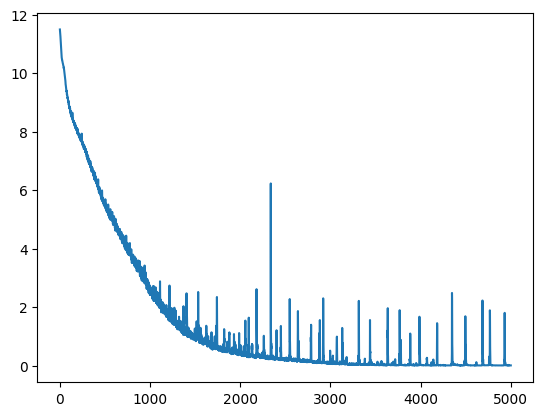

In [35]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_3, dtype=torch.float32), torch.tensor(y_train_3, dtype=torch.float32)),
    batch_size=64, shuffle=True)

rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

### Train keys4

  2%|▏         | 101/5000 [00:12<10:33,  7.73it/s]

100 10.757121294736862


  4%|▍         | 201/5000 [00:25<08:45,  9.13it/s]

200 10.21109363436699


  6%|▌         | 301/5000 [00:38<10:11,  7.69it/s]

...

4800 0.021971341979224235


 98%|█████████▊| 4901/5000 [12:00<00:16,  5.98it/s]

4900 0.15195246881921776


100%|██████████| 5000/5000 [12:17<00:00,  6.78it/s]


5000 0.18592103582341224
acc= 0.5356371402740479


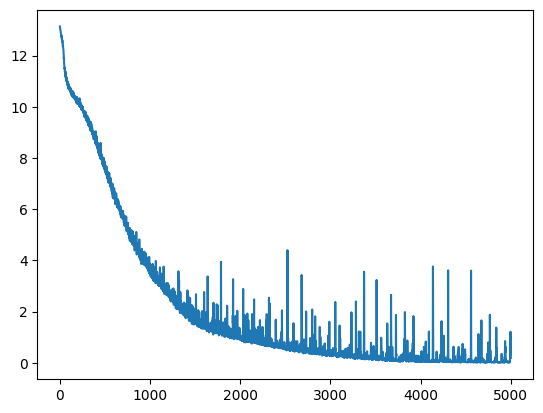

In [36]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_4, dtype=torch.float32), torch.tensor(y_train_4, dtype=torch.float32)),
    batch_size=64, shuffle=True)

rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())